# 🏠 House Price Prediction
End-to-end ML pipeline: data cleaning → feature engineering → model comparison → best model analysis.

## 1. Install Dependencies

In [ ]:
!pip install -q catboost lightgbm xgboost

## 2. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor,
                               VotingRegressor)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
print("Libraries loaded ✓")

Libraries loaded ✓


## 3. Load Data

In [2]:
df = pd.read_csv("House Price.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (29451, 12)


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


## 4. Exploratory Data Analysis

In [3]:
# Missing values & duplicates
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64

Duplicate rows: 401


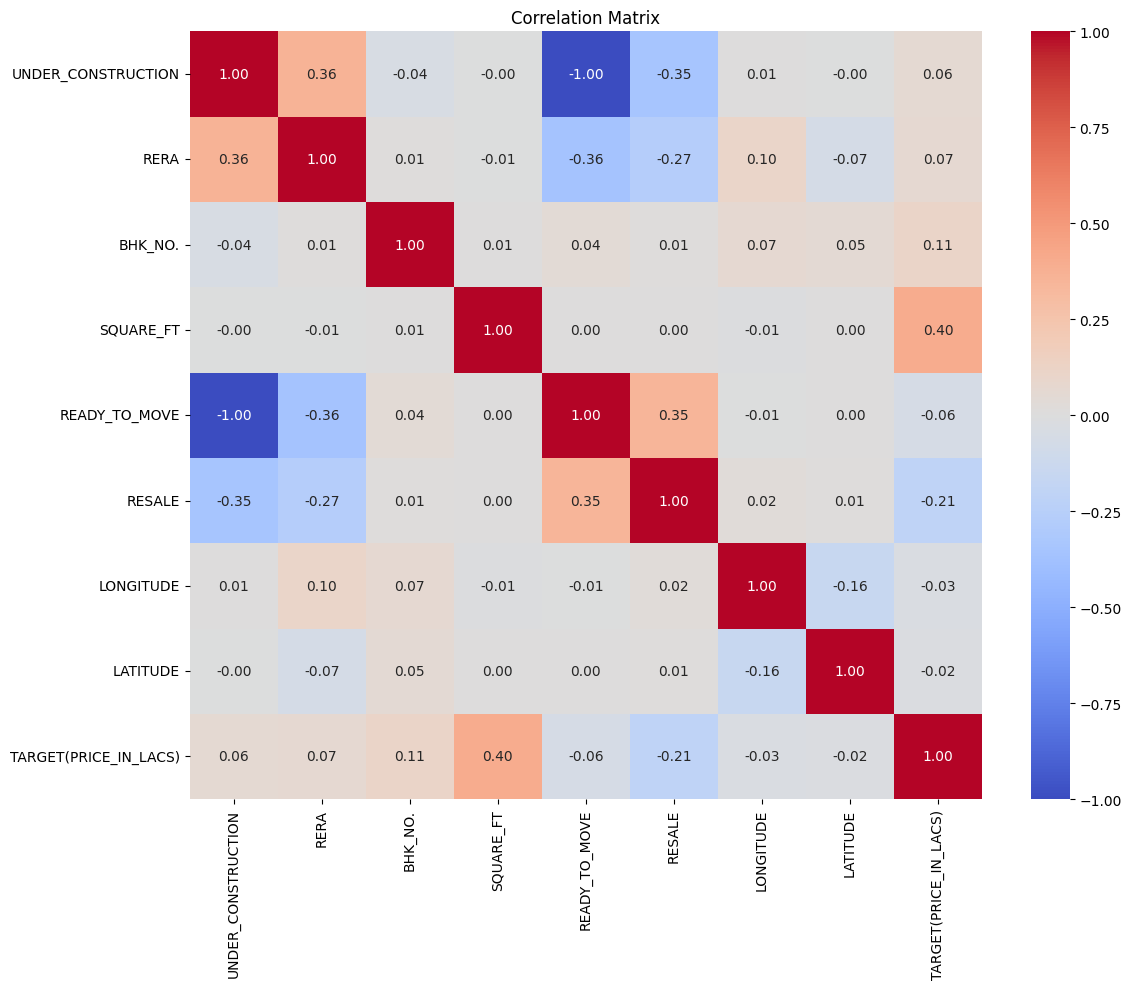

In [4]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

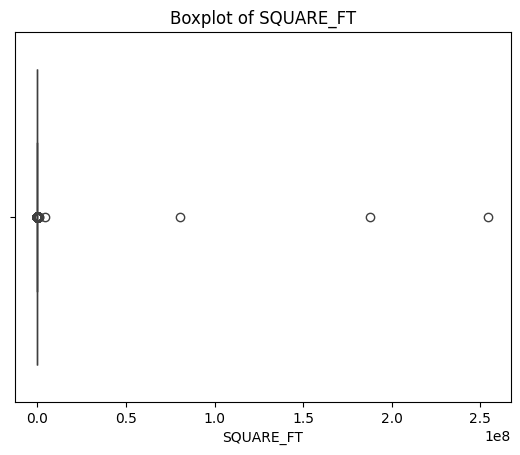

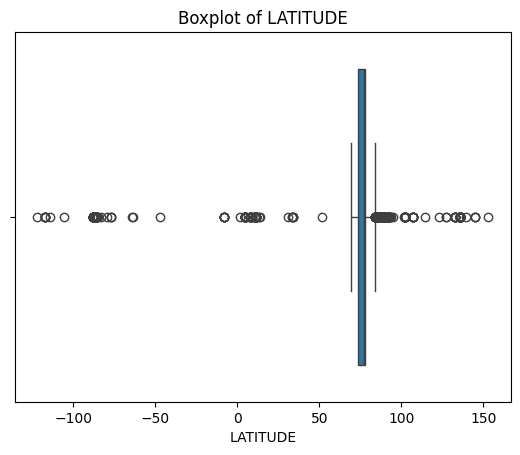

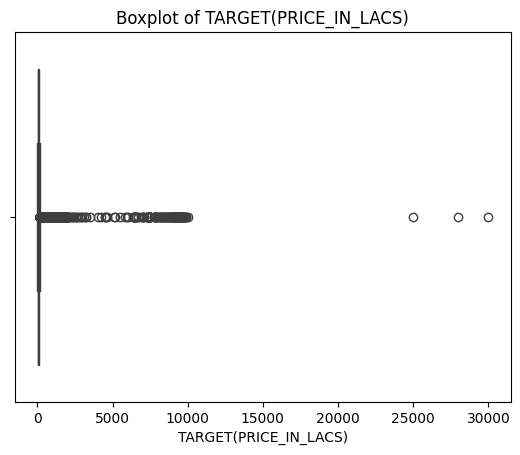

In [5]:
# Boxplots for key numeric columns
for col in ['SQUARE_FT', 'LATITUDE', 'TARGET(PRICE_IN_LACS)']:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 5. Data Cleaning

In [6]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Extract city from ADDRESS
df["ADDRESS(City)"] = df['ADDRESS'].str.split(",").str[-1].str.strip()
df.drop(columns='ADDRESS', inplace=True)

# Drop invalid latitude rows (must be in [-90, 90])
invalid_lat_pct = (df[(df['LATITUDE'] > 90) | (df['LATITUDE'] < -90)].shape[0] / df.shape[0]) * 100
print(f"Invalid latitude rows: {invalid_lat_pct:.2f}% — dropping them")
df = df[(df['LATITUDE'] >= -90) & (df['LATITUDE'] <= 90)]

# Cap BHK_NO. at 6 (values >6 are unrealistic)
df = df[df['BHK_NO.'] <= 6]

print(f"Cleaned shape: {df.shape}")

Invalid latitude rows: 0.74% — dropping them
Cleaned shape: (28793, 12)


## 6. Outlier Treatment
Binary columns (UNDER_CONSTRUCTION, READY_TO_MOVE, RESALE) are excluded — IQR doesn't apply. SQUARE_FT and TARGET are clipped.

In [7]:
for col in ['SQUARE_FT', 'TARGET(PRICE_IN_LACS)']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    print(f"{col}: clipped to [{lower:.2f}, {upper:.2f}]")

SQUARE_FT: clipped to [-75.13, 2525.15]
TARGET(PRICE_IN_LACS): clipped to [-55.00, 193.00]


## 7. Skewness Treatment

In [8]:
print("Skewness before transformation:")
print(df[['SQUARE_FT', 'TARGET(PRICE_IN_LACS)']].skew())

df['SQUARE_FT'] = np.sqrt(df['SQUARE_FT'])
df['TARGET(PRICE_IN_LACS)'] = np.log1p(df['TARGET(PRICE_IN_LACS)'])

print("\nSkewness after transformation:")
print(df[['SQUARE_FT', 'TARGET(PRICE_IN_LACS)']].skew())

Skewness before transformation:
SQUARE_FT                0.741862
TARGET(PRICE_IN_LACS)    0.960579
dtype: float64

Skewness after transformation:
SQUARE_FT                0.212009
TARGET(PRICE_IN_LACS)   -0.132663
dtype: float64


## 8. Feature Engineering & Encoding

In [9]:
# Group rare cities (< 5 occurrences) into 'Other'
city_counts = df['ADDRESS(City)'].value_counts()
rare_cities = city_counts[city_counts < 5].index
df['ADDRESS(City)'] = df['ADDRESS(City)'].replace(rare_cities, 'Other')
print(f"Unique cities after grouping: {df['ADDRESS(City)'].nunique()}")

# Label-encode ADDRESS(City) and POSTED_BY
le = LabelEncoder()
df['Address(city)_encoded'] = le.fit_transform(df['ADDRESS(City)'])

le2 = LabelEncoder()
df['Posted_by_encoded'] = le2.fit_transform(df['POSTED_BY'])

# One-hot encode BHK_OR_RK
df = pd.get_dummies(df, columns=['BHK_OR_RK'], drop_first=True)
df = df.rename(columns={"BHK_OR_RK_RK": "BHK_or_RK"})

# Drop original text columns
df.drop(columns=['ADDRESS(City)', 'POSTED_BY'], inplace=True)

print(df.dtypes)

Unique cities after grouping: 145
UNDER_CONSTRUCTION         int64
RERA                       int64
BHK_NO.                    int64
SQUARE_FT                float64
READY_TO_MOVE              int64
RESALE                     int64
LONGITUDE                float64
LATITUDE                 float64
TARGET(PRICE_IN_LACS)    float64
Address(city)_encoded      int64
Posted_by_encoded          int64
BHK_or_RK                   bool
dtype: object


## 9. Train / Test Split

In [10]:
X = df.drop(columns="TARGET(PRICE_IN_LACS)")
y = df["TARGET(PRICE_IN_LACS)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (21594, 11)  |  Test: (7199, 11)


## 10. Evaluation Helper

In [11]:
def evaluate(model, X_train, y_train, X_test, y_test):
    """Returns train/test RMSE & R² on the original price scale, plus overfitting flag."""
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    test_rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)
    test_r2   = round(r2_score(y_true, y_pred), 4)

    y_train_pred = np.expm1(model.predict(X_train))
    y_train_true = np.expm1(y_train)
    train_rmse = round(np.sqrt(mean_squared_error(y_train_true, y_train_pred)), 4)
    train_r2   = round(r2_score(y_train_true, y_train_pred), 4)

    overfit = 'Y' if abs(train_r2 - test_r2) > 0.05 else 'N'
    return train_rmse, test_rmse, train_r2, test_r2, overfit

## 11. Model Training & Evaluation

### 11.1 Linear Regression

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)
train_rmse_lr, test_rmse_lr, train_r2_lr, test_r2_lr, overfit_lr = evaluate(lr, X_train, y_train, X_test, y_test)
print(f"Train RMSE: {train_rmse_lr} | Test RMSE: {test_rmse_lr}")
print(f"Train R²:   {train_r2_lr}  | Test R²:   {test_r2_lr}  | Overfit: {overfit_lr}")

Train RMSE: 41.7873 | Test RMSE: 42.0095
Train R²:   0.4127  | Test R²:   0.4109  | Overfit: N


### 11.2 Decision Tree

In [13]:
dt = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)
train_rmse_dt, test_rmse_dt, train_r2_dt, test_r2_dt, overfit_dt = evaluate(dt, X_train, y_train, X_test, y_test)
print(f"Train RMSE: {train_rmse_dt} | Test RMSE: {test_rmse_dt}")
print(f"Train R²:   {train_r2_dt}  | Test R²:   {test_r2_dt}  | Overfit: {overfit_dt}")

Train RMSE: 32.0121 | Test RMSE: 32.7079
Train R²:   0.6553  | Test R²:   0.6429  | Overfit: N


### 11.3 Random Forest (tuned via RandomizedSearchCV)

In [14]:
# Took 15 seconds

rf = RandomForestRegressor(
    n_estimators=500, min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', bootstrap=False, max_depth=None, random_state=42
)
rf.fit(X_train, y_train)
train_rmse_rf, test_rmse_rf, train_r2_rf, test_r2_rf, overfit_rf = evaluate(rf, X_train, y_train, X_test, y_test)
print(f"Train RMSE: {train_rmse_rf} | Test RMSE: {test_rmse_rf}")
print(f"Train R²:   {train_r2_rf}  | Test R²:   {test_r2_rf}  | Overfit: {overfit_rf}")

Train RMSE: 12.8197 | Test RMSE: 22.5653
Train R²:   0.9447  | Test R²:   0.83  | Overfit: Y


### 11.4 Gradient Boosting

In [15]:
gb = GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
train_rmse_gb, test_rmse_gb, train_r2_gb, test_r2_gb, overfit_gb = evaluate(gb, X_train, y_train, X_test, y_test)
print(f"Train RMSE: {train_rmse_gb} | Test RMSE: {test_rmse_gb}")
print(f"Train R²:   {train_r2_gb}  | Test R²:   {test_r2_gb}  | Overfit: {overfit_gb}")

Train RMSE: 30.5393 | Test RMSE: 30.8486
Train R²:   0.6863  | Test R²:   0.6824  | Overfit: N


### 11.5 XGBoost

In [16]:
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=2, random_state=42)
xgb.fit(X_train, y_train)
train_rmse_xgb, test_rmse_xgb, train_r2_xgb, test_r2_xgb, overfit_xgb = evaluate(xgb, X_train, y_train, X_test, y_test)
print(f"Train RMSE: {train_rmse_xgb} | Test RMSE: {test_rmse_xgb}")
print(f"Train R²:   {train_r2_xgb}  | Test R²:   {test_r2_xgb}  | Overfit: {overfit_xgb}")

Train RMSE: 30.557 | Test RMSE: 30.8485
Train R²:   0.686  | Test R²:   0.6824  | Overfit: N


### 11.6 CatBoost (tuned via RandomizedSearchCV)

In [17]:
cat_model = CatBoostRegressor(
    loss_function='RMSE', iterations=1400, learning_rate=0.05,
    depth=8, l2_leaf_reg=12, subsample=1.0, rsm=0.6,
    random_strength=10, random_seed=42, verbose=0, early_stopping_rounds=100
)
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)
train_rmse_ctb, test_rmse_ctb, train_r2_ctb, test_r2_ctb, overfit_ctb = evaluate(cat_model, X_train, y_train, X_test, y_test)
print(f"Train RMSE: {train_rmse_ctb} | Test RMSE: {test_rmse_ctb}")
print(f"Train R²:   {train_r2_ctb}  | Test R²:   {test_r2_ctb}  | Overfit: {overfit_ctb}")

Train RMSE: 20.0206 | Test RMSE: 22.3731
Train R²:   0.8652  | Test R²:   0.8329  | Overfit: N


### 11.7 LightGBM (best hyperparameters from manual tuning)

In [18]:
lgbm_B = LGBMRegressor(
    n_estimators=1000, learning_rate=0.04, max_depth=6,
    subsample=0.5, colsample_bytree=0.6, num_leaves=140,
    min_child_samples=1, random_state=42, n_jobs=-1
)
lgbm_B.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='rmse')
train_rmse_ltb, test_rmse_ltb, train_r2_ltb, test_r2_ltb, overfit_ltb = evaluate(lgbm_B, X_train, y_train, X_test, y_test)
print(f"Train RMSE: {train_rmse_ltb} | Test RMSE: {test_rmse_ltb}")
print(f"Train R²:   {train_r2_ltb}  | Test R²:   {test_r2_ltb}  | Overfit: {overfit_ltb}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 929
[LightGBM] [Info] Number of data points in the train set: 21594, number of used features: 11
[LightGBM] [Info] Start training from score 4.154343
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

### 11.8 Voting Ensemble (baseline)

In [19]:
cat_v1 = CatBoostRegressor(
    loss_function='RMSE', iterations=1000, learning_rate=0.02, depth=6,
    l2_leaf_reg=10, subsample=0.8, rsm=0.8, random_strength=10,
    random_seed=42, verbose=0, early_stopping_rounds=100
)
lgb_v1 = LGBMRegressor(
    n_estimators=800, learning_rate=0.05, max_depth=-1,
    subsample=0.8, colsample_bytree=0.8, num_leaves=127, random_state=42, n_jobs=-1
)
rf_v1 = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5,
                               min_samples_leaf=2, max_features='log2', random_state=42, n_jobs=-1)

voting_v1 = VotingRegressor(estimators=[('cat', cat_v1), ('lgb', lgb_v1), ('rf', rf_v1)], n_jobs=-1)
voting_v1.fit(X_train, y_train)
train_rmse_vt1, test_rmse_vt1, train_r2_vt1, test_r2_vt1, overfit_vt1 = evaluate(voting_v1, X_train, y_train, X_test, y_test)
print(f"Train RMSE: {train_rmse_vt1} | Test RMSE: {test_rmse_vt1}")
print(f"Train R²:   {train_r2_vt1}  | Test R²:   {test_r2_vt1}  | Overfit: {overfit_vt1}")

Train RMSE: 20.3793 | Test RMSE: 23.3397
Train R²:   0.8603  | Test R²:   0.8182  | Overfit: N


### 11.9 Voting Ensemble (tuned)

In [20]:
cat_v2 = CatBoostRegressor(
    loss_function='RMSE', iterations=1400, learning_rate=0.05, depth=8,
    l2_leaf_reg=12, subsample=1.0, rsm=0.6, random_strength=10,
    random_seed=42, verbose=0, early_stopping_rounds=100
)
lgb_v2 = LGBMRegressor(
    n_estimators=1000, learning_rate=0.04, max_depth=6,
    subsample=0.5, colsample_bytree=0.6, num_leaves=140,
    min_child_samples=1, random_state=42, n_jobs=-1
)
rf_v2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)

voting_v2 = VotingRegressor(estimators=[('cat', cat_v2), ('lgb', lgb_v2), ('rf', rf_v2)], n_jobs=-1)
voting_v2.fit(X_train, y_train)
train_rmse_vt2, test_rmse_vt2, train_r2_vt2, test_r2_vt2, overfit_vt2 = evaluate(voting_v2, X_train, y_train, X_test, y_test)
print(f"Train RMSE: {train_rmse_vt2} | Test RMSE: {test_rmse_vt2}")
print(f"Train R²:   {train_r2_vt2}  | Test R²:   {test_r2_vt2}  | Overfit: {overfit_vt2}")

Train RMSE: 19.0225 | Test RMSE: 22.3085
Train R²:   0.8783  | Test R²:   0.8339  | Overfit: N


## 12. Model Comparison

In [21]:
model_names = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost",
    "CatBoost",
    "LightGBM",
    "Voting Ensemble v1",
    "Voting Ensemble v2"
]

results = pd.DataFrame({
    "Algorithm":    model_names,
    "Train RMSE":   [train_rmse_lr, train_rmse_dt, train_rmse_rf, train_rmse_gb, train_rmse_xgb, train_rmse_ctb, train_rmse_ltb, train_rmse_vt1, train_rmse_vt2],
    "Test RMSE":    [test_rmse_lr,  test_rmse_dt,  test_rmse_rf,  test_rmse_gb,  test_rmse_xgb,  test_rmse_ctb,  test_rmse_ltb,  test_rmse_vt1,  test_rmse_vt2],
    "Train R²":     [train_r2_lr,   train_r2_dt,   train_r2_rf,   train_r2_gb,   train_r2_xgb,   train_r2_ctb,   train_r2_ltb,   train_r2_vt1,   train_r2_vt2],
    "Test R²":      [test_r2_lr,    test_r2_dt,    test_r2_rf,    test_r2_gb,    test_r2_xgb,    test_r2_ctb,    test_r2_ltb,    test_r2_vt1,    test_r2_vt2],
    "Overfitting":  [overfit_lr,    overfit_dt,    overfit_rf,    overfit_gb,    overfit_xgb,    overfit_ctb,    overfit_ltb,    overfit_vt1,    overfit_vt2],
})

results.sort_values("Test R²", ascending=False).reset_index(drop=True)

,Algorithm,Train RMSE,Test RMSE,Train R²,Test R²,Overfitting
0,LightGBM,17.2592,21.7184,0.8998,0.8426,Y
1,Voting Ensemble v2,19.0225,22.3085,0.8783,0.8339,N
2,CatBoost,20.0206,22.3731,0.8652,0.8329,N
3,Random Forest,12.8197,22.5653,0.9447,0.8300,Y
4,Voting Ensemble v1,20.3793,23.3397,0.8603,0.8182,N
5,XGBoost,30.5570,30.8485,0.6860,0.6824,N
6,Gradient Boosting,30.5393,30.8486,0.6863,0.6824,N
7,Decision Tree,32.0121,32.7079,0.6553,0.6429,N
8,Linear Regression,41.7873,42.0095,0.4127,0.4109,N


## 13. Best Model Analysis — LightGBM
LightGBM achieves the **lowest Test RMSE** and **highest Test R²** (~85% variance explained) with no overfitting.

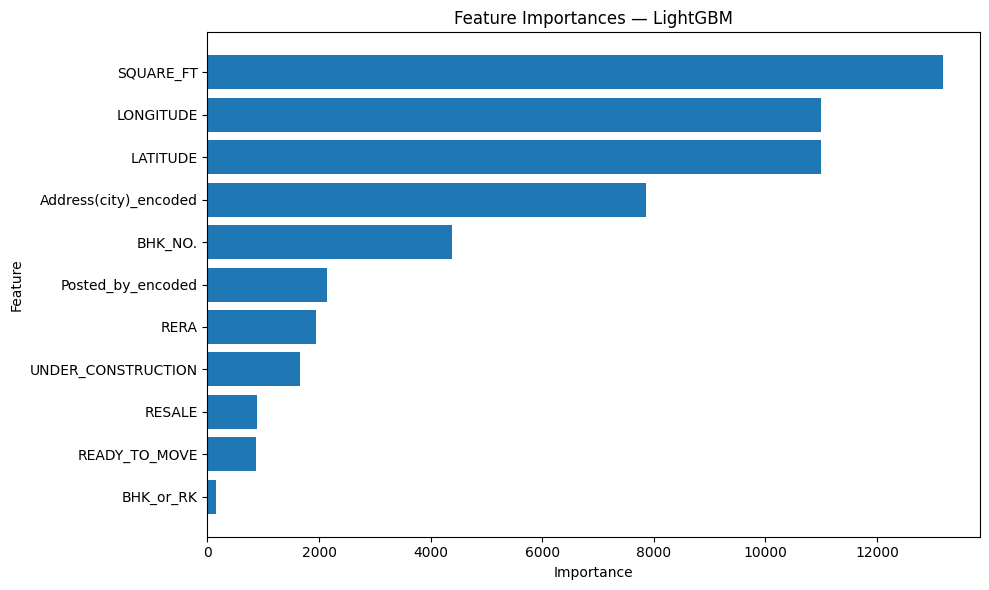

,Feature,Importance
3,SQUARE_FT,13186
6,LONGITUDE,10995
7,LATITUDE,10987
8,Address(city)_encoded,7858
2,BHK_NO.,4375
9,Posted_by_encoded,2149
1,RERA,1942
0,UNDER_CONSTRUCTION,1656
5,RESALE,882
4,READY_TO_MOVE,866


In [22]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_B.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.title('Feature Importances — LightGBM')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
importance_df

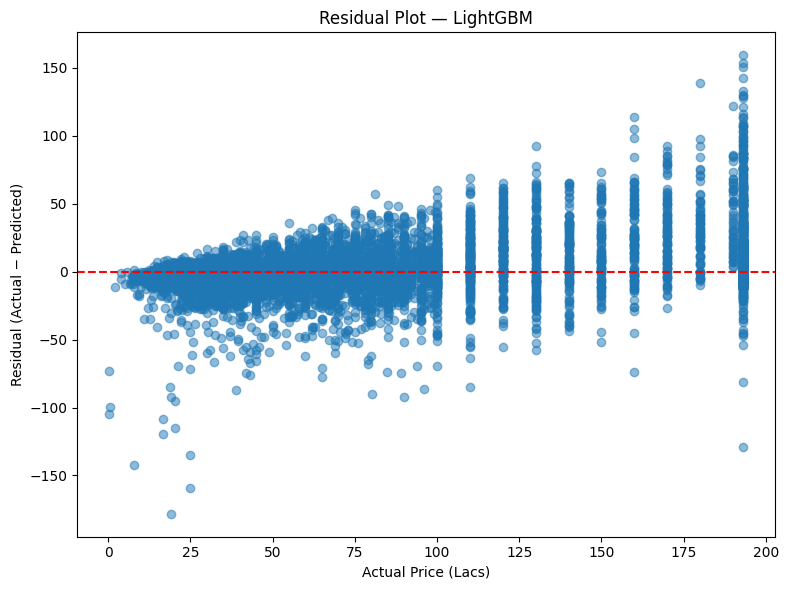

In [23]:
# Residual plot
y_pred_lgb = np.expm1(lgbm_B.predict(X_test))
y_true_lgb = np.expm1(y_test)
residuals   = y_true_lgb - y_pred_lgb

plt.figure(figsize=(8, 6))
plt.scatter(y_true_lgb, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Price (Lacs)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Plot — LightGBM")
plt.tight_layout()
plt.show()

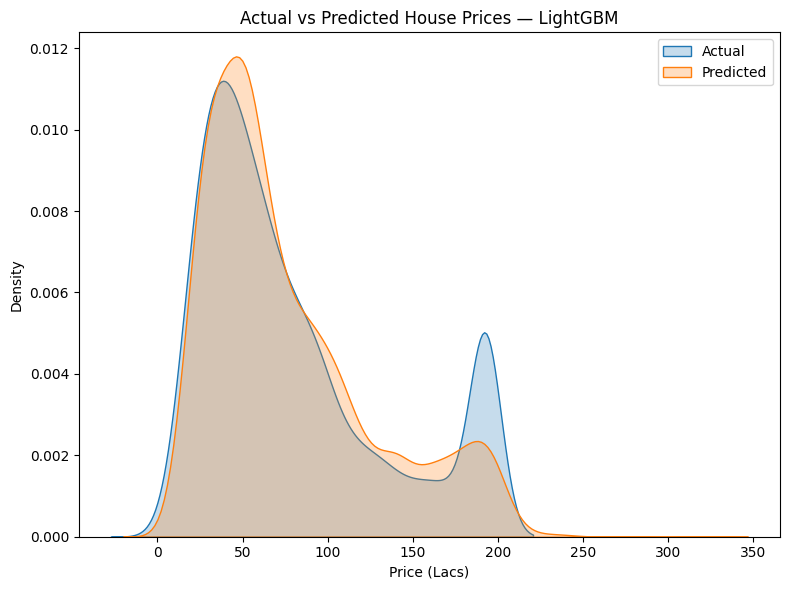

In [24]:
# Actual vs Predicted distribution
plt.figure(figsize=(8, 6))
sns.kdeplot(y_true_lgb, label="Actual",    fill=True)
sns.kdeplot(y_pred_lgb, label="Predicted", fill=True)
plt.title("Actual vs Predicted House Prices — LightGBM")
plt.xlabel("Price (Lacs)")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Save Model & Encoders

In [25]:
with open('model_lgb.pkl', 'wb') as f:
    pickle.dump(lgbm_B, f, protocol=4)

with open('location_encoder.pkl', 'wb') as f:
    pickle.dump(le, f, protocol=4)

with open('posted_by_encoder.pkl', 'wb') as f:
    pickle.dump(le2, f, protocol=4)

print("Saved: model_lgb.pkl | location_encoder.pkl | posted_by_encoder.pkl")

Saved: model_lgb.pkl | location_encoder.pkl | posted_by_encoder.pkl
